In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1'
os.chdir(project_path)

print("Current Directory:", os.getcwd())

Current Directory: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1


In [3]:
import os

# Set your Informer data directory
informer_path = f'{project_path}/Informer2020-original'
data_dir = f'{informer_path}/data/ETT'
os.makedirs(data_dir, exist_ok=True)

# File path
data_file = f'{data_dir}/ETTh1.csv'

# Download ETTh1 dataset
if not os.path.exists(data_file):
    print("Downloading ETTh1.csv...")
    os.system(
        f'wget -q "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv" '
        f'-O "{data_file}"'
    )

# Verify
if os.path.exists(data_file):
    print(f"✅ Download successful: {data_file}")
else:
    print("❌ Download failed.")

✅ Download successful: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/data/ETT/ETTh1.csv


In [4]:
# Fix np.Inf -> np.inf in tools.py (removed in NumPy 2.0)
tools_path = f'{project_path}/Informer2020-original/utils/tools.py'

with open(tools_path, 'r') as f:
    content = f.read()

content_fixed = content.replace('np.Inf', 'np.inf')

with open(tools_path, 'w') as f:
    f.write(content_fixed)

print("✅ Fixed np.Inf -> np.inf in utils/tools.py")

✅ Fixed np.Inf -> np.inf in utils/tools.py


In [9]:
!rm -rf "/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/logs/exp6_lod_pre_phase1"

In [10]:
!bash /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/experiments/exp6_lod_pre/exp6_lod_pre_phase1.sh

 Experiment 6 LOD Pre-Softmax — Phase 1: Alpha Screening
 Date: Sun Aug 16 08:08:58 AM UTC 2026
------------------------------------------------------------
 Architecture:
   Q, K  ← combined_emb  (value + temporal + legendre)
   V     ← delta_x       (x_i - x_{i-1})
   alpha = 1/(1 + |i-j|^decay_a)  applied BEFORE softmax
------------------------------------------------------------
 Alpha sweep:   decay_a in {0.5, 1.0, 2.0}
 Pred lens:     96, 192
 Seed:          2021 (Phase 1 only)
 Total runs:    6  (3 alpha × 2 pred_len × 1 seed)
------------------------------------------------------------
 Bug fixes applied before run:
   FINDING F: InformerStack decay_a threading + forward() tuple fix
   FINDING G: delta_x downsampling through ConvLayer
   FINDING H: exp_informer.py now forwards --decay_a to model
------------------------------------------------------------
 Reference results (Exp1-Pre, alpha=1.0, seed=2021):
   pred_len=96  → MSE ~0.8683  [update with actuals from logs]
   pred_

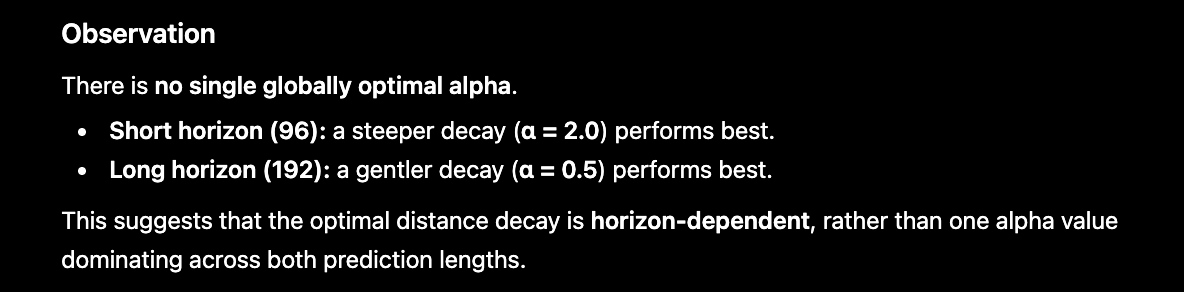

ALPHA - 2.0 Phase 2 below


In [11]:
!bash /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/experiments/exp6_lod_pre/exp6_lod_pre_phase2_a2.0.sh

 Experiment 6 LOD Pre-Softmax — Phase 2: Stability Validation (decay_a=2.0)
 Date: Sun Aug 16 08:56:19 AM UTC 2026
------------------------------------------------------------
 Architecture:
   Q, K  ← combined_emb  (value + temporal + legendre)
   V     ← delta_x       (x_i - x_{i-1})
   alpha = 1/(1 + |i-j|^decay_a)  applied BEFORE softmax
------------------------------------------------------------
 decay_a fixed at 2.0 (best alpha for pred=96 from Phase 1)
 Pred lens:     48, 96, 192, 336
 Seeds:         2021, 2022, 2023
 Total runs:    12  (4 pred_lens × 3 seeds)
------------------------------------------------------------
 Phase 1 results (seed=2021):
   decay_a=2.0: pred_96  MSE=0.9629  MAE=0.7839
   decay_a=2.0: pred_192 MSE=0.9780  MAE=0.7907
   (decay_a=0.5 was best at pred_192: MSE=0.9075)

Copying model files to /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/models/ ...
File copy complete (7 files + legendre_embedding.py in models/ and root).

-----

ALPHA - 0.5 Phase 2 below


In [12]:
!bash /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/experiments/exp6_lod_pre/exp6_lod_pre_phase2_a0.5.sh

 Experiment 6 LOD Pre-Softmax — Phase 2: Stability Validation (decay_a=0.5)
 Date: Sun Aug 16 10:12:47 AM UTC 2026
------------------------------------------------------------
 Architecture:
   Q, K  ← combined_emb  (value + temporal + legendre)
   V     ← delta_x       (x_i - x_{i-1})
   alpha = 1/(1 + |i-j|^decay_a)  applied BEFORE softmax
------------------------------------------------------------
 decay_a fixed at 0.5 (best alpha for pred=192 from Phase 1)
 Pred lens:     48, 96, 192, 336
 Seeds:         2021, 2022, 2023
 Total runs:    12  (4 pred_lens × 3 seeds)
------------------------------------------------------------
 Phase 1 results (seed=2021):
   decay_a=0.5: pred_96  MSE=0.9849  MAE=0.8068
   decay_a=0.5: pred_192 MSE=0.9075  MAE=0.7574  ← best at pred=192
   (decay_a=2.0 was best at pred_96: MSE=0.9629)

Copying model files to /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/models/ ...
File copy complete (7 files + legendre_embedding.py in model